In [4]:
import pandas as pd
df = pd.read_csv('train.csv', encoding = 'latin1')
df.head()
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [8]:

df['Order Date'].dtype
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')

In [9]:
import pandas as pd

snapshot_date = df['Order Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency=('Order Date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Order ID', 'nunique'),
    Monetary=('Sales', 'sum')
).reset_index()

rfm.head()
rfm.describe()

,Recency,Frequency,Monetary
count,793.000000,793.000000,793.000000
mean,149.286255,6.206810,2851.874884
std,187.081466,2.525647,2620.668723
min,1.000000,1.000000,4.833000
25%,31.000000,4.000000,1081.466000
50%,76.000000,6.000000,2215.002000
75%,185.000000,8.000000,3670.258000
max,1166.000000,17.000000,25043.050000


In [21]:
import numpy as np
class StandardScaler:
    def fit_transform(self, data):
        data = np.asarray(data, dtype=float)
        self.mean_ = data.mean(axis=0)
        self.scale_ = data.std(axis=0)
        self.scale_[self.scale_ == 0] = 1
        return (data - self.mean_) / self.scale_

rfm['Recency_log'] = np.log1p(rfm['Recency'])
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])

# Use log-transformed Recency & Monetary, plus raw Frequency
features = rfm[['Recency_log', 'Frequency', 'Monetary_log']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

scaled_features[:5]  # preview first 5 rows


array([[ 0.71987378, -0.47812351,  1.01933267],
       [-1.0057    ,  1.1066286 , -0.53232935],
       [ 0.98787881, -0.87431153, -0.03966609],
       [-0.2157605 , -0.08193548,  0.93566187],
       [ 1.35856279, -1.27049956, -0.69635041]])

In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler
# silhouette_score is not required in this cell
# silhouette_score is not required in this cell
import matplotlib.pyplot as plt

df = pd.read_csv('train.csv', encoding='latin1')
df = df.dropna(subset=['Postal Code'])
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')

snapshot_date = df['Order Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency=('Order Date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Order ID', 'nunique'),
    Monetary=('Sales', 'sum')
).reset_index()

rfm['Recency_log'] = np.log1p(rfm['Recency'])
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])

features = rfm[['Recency_log', 'Frequency', 'Monetary_log']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

scaled_features[:5]

array([[ 0.71667451, -0.47576496,  1.02417184],
       [-1.00757999,  1.11111879, -0.52871378],
       [ 0.98447463, -0.87248589, -0.03566202],
       [-0.21824444, -0.07904402,  0.94043507],
       [ 1.35487521, -1.26920683, -0.69286418]])

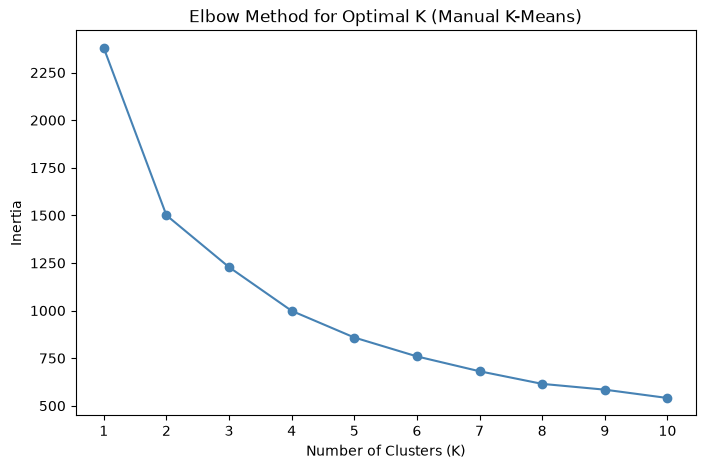

In [30]:
import numpy as np

def kmeans_manual(X, k, max_iters=100, random_state=42):
    np.random.seed(random_state)
    n_samples, n_features = X.shape
    
    random_idx = np.random.choice(n_samples, k, replace=False)
    centroids = X[random_idx]
    
    for _ in range(max_iters):
        distances = np.array([np.linalg.norm(X - c, axis=1) for c in centroids])
        labels = np.argmin(distances, axis=0)
        
        new_centroids = np.array([X[labels == i].mean(axis=0) if np.any(labels == i) else centroids[i] for i in range(k)])
        
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
    
    inertia = sum(np.linalg.norm(X[labels == i] - centroids[i])**2 for i in range(k))
    return labels, centroids, inertia

inertias = []
K_range = range(1, 11)
for k in K_range:
    _, _, inertia = kmeans_manual(scaled_features, k)
    inertias.append(inertia)

import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(K_range, inertias, marker='o', color='steelblue')
plt.title('Elbow Method for Optimal K (Manual K-Means)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.show()


In [31]:
labels, centroids, inertia = kmeans_manual(scaled_features, k=4)

rfm['Cluster'] = labels
rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)


,Recency,Frequency,Monetary
Cluster,,,
0,96.27,9.02,4714.79
1,23.91,6.31,2710.36
2,252.94,4.71,2127.67
3,288.41,2.99,270.58


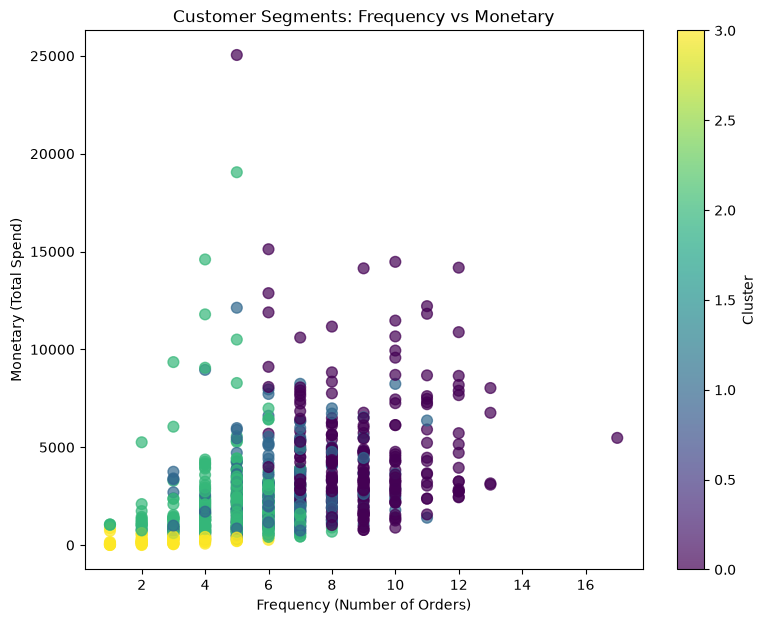

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,7))
scatter = plt.scatter(rfm['Frequency'], rfm['Monetary'], c=rfm['Cluster'], cmap='viridis', alpha=0.7, s=60)
plt.title('Customer Segments: Frequency vs Monetary')
plt.xlabel('Frequency (Number of Orders)')
plt.ylabel('Monetary (Total Spend)')
plt.colorbar(scatter, label='Cluster')
plt.show()


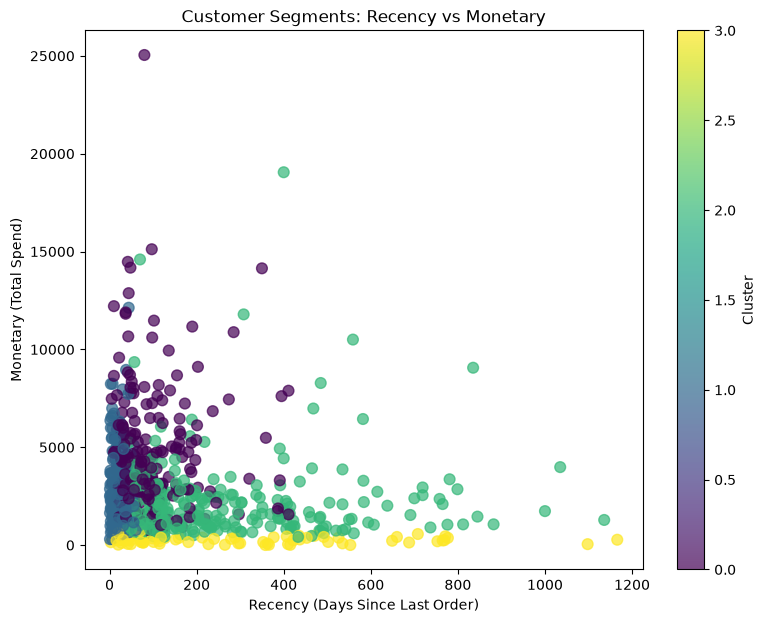

In [33]:
plt.figure(figsize=(9,7))
scatter = plt.scatter(rfm['Recency'], rfm['Monetary'], c=rfm['Cluster'], cmap='viridis', alpha=0.7, s=60)
plt.title('Customer Segments: Recency vs Monetary')
plt.xlabel('Recency (Days Since Last Order)')
plt.ylabel('Monetary (Total Spend)')
plt.colorbar(scatter, label='Cluster')
plt.show()

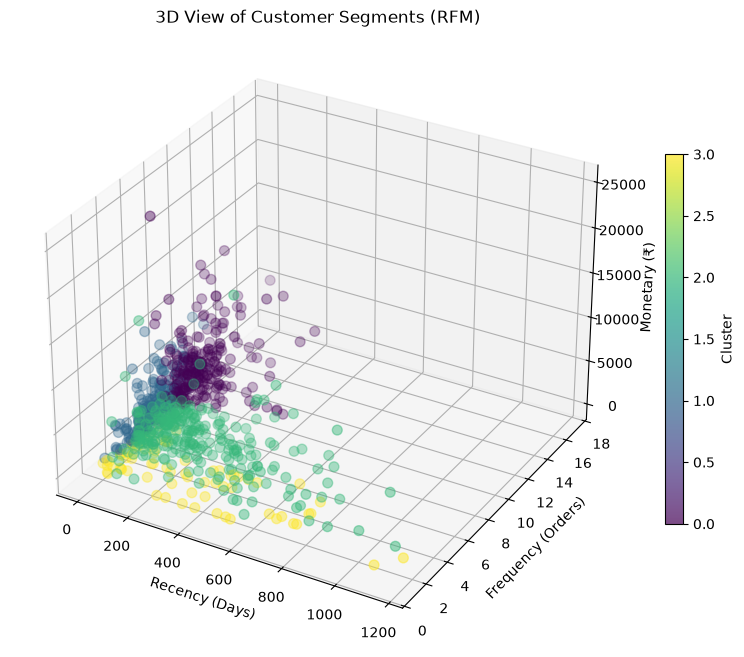

In [34]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(rfm['Recency'], rfm['Frequency'], rfm['Monetary'], 
                      c=rfm['Cluster'], cmap='viridis', alpha=0.7, s=50)
ax.set_xlabel('Recency (Days)')
ax.set_ylabel('Frequency (Orders)')
ax.set_zlabel('Monetary (₹)')
ax.set_title('3D View of Customer Segments (RFM)')
plt.colorbar(scatter, label='Cluster', shrink=0.6)
plt.show()
